# Notebook 3 — Machine Learning: Predicting High-Value Customers
### Project: Retail Sales & Customer Purchase Prediction (Group A)

**Goal:** Predict which customers will become **high-value** in a future period, using only information
we could have observed *before* that period. This notebook builds the leakage-safe target defined in
Notebook 1, trains a baseline, Logistic Regression, and Random Forest, and evaluates all three honestly.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)

RANDOM_STATE = 42
CHART_DIR = "../outputs/charts"
MODEL_RESULTS_DIR = "../outputs/model_results"
MODEL_READY_DIR = "../data/model_ready"
os.makedirs(MODEL_RESULTS_DIR, exist_ok=True)
os.makedirs(MODEL_READY_DIR, exist_ok=True)

## 1. Load the Cleaned Valid-Sales Dataset (from Notebook 2)

We build on the already-cleaned data — cancellations, admin codes, invalid quantities/prices and missing
Customer IDs were already excluded in Notebook 2.

In [2]:
valid_sales = pd.read_csv("../data/cleaned/online_retail_valid_sales.csv", parse_dates=['InvoiceDate'])
print("Valid sales loaded:", valid_sales.shape)
print("Date range:", valid_sales['InvoiceDate'].min(), "to", valid_sales['InvoiceDate'].max())

Valid sales loaded: (776624, 22)
Date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00


## 2. Define the Prediction Scenario (Leakage-Safe Time Split)

**Business scenario:** *"Based on a customer's purchase history up to a cutoff date, will they become a
high-value customer in the following period?"*

- **Cutoff date: 2010-12-01** — splits the ~24-month dataset roughly in half
- **Feature period** (before cutoff): used only to build historical behavior features
- **Target period** (cutoff onward): used only to compute the label
- Candidate customers = everyone who purchased during the feature period. If they don't return in the
  target period at all, their target-period spend is **0** — this is a real, valid outcome (churn), not
  missing data.

This guarantees no feature is calculated using data the model would not have had "at prediction time".

In [3]:
cutoff_date = pd.Timestamp("2010-12-01")

feature_period = valid_sales[valid_sales['InvoiceDate'] < cutoff_date].copy()
target_period = valid_sales[valid_sales['InvoiceDate'] >= cutoff_date].copy()

print("Feature period :", feature_period['InvoiceDate'].min(), "to", feature_period['InvoiceDate'].max(),
      "|", len(feature_period), "rows |", feature_period['Customer ID'].nunique(), "customers")
print("Target period  :", target_period['InvoiceDate'].min(), "to", target_period['InvoiceDate'].max(),
      "|", len(target_period), "rows |", target_period['Customer ID'].nunique(), "customers")

Feature period : 2009-12-01 07:45:00 to 2010-11-30 19:35:00 | 385474 rows | 4249 customers
Target period  : 2010-12-01 08:26:00 to 2011-12-09 12:50:00 | 391150 rows | 4334 customers


## 3. Build Historical (Feature-Period) Customer Features

Every feature below is computed **only from the feature period** — none of them use any information from
the target period, so none of them can leak the label.

In [4]:
feat_snapshot = feature_period['InvoiceDate'].max() + pd.Timedelta(days=1)

hist_features = feature_period.groupby('Customer ID').agg(
    HistTotalSpend=('TotalAmount', 'sum'),
    HistNumOrders=('Invoice', 'nunique'),
    HistNumItems=('Quantity', 'sum'),
    HistNumUniqueProducts=('StockCode', 'nunique'),
    HistLastPurchaseDate=('InvoiceDate', 'max'),
    HistFirstPurchaseDate=('InvoiceDate', 'min')
).reset_index()

hist_features['HistAvgOrderValue'] = hist_features['HistTotalSpend'] / hist_features['HistNumOrders']
hist_features['HistRecencyDays'] = (feat_snapshot - hist_features['HistLastPurchaseDate']).dt.days
hist_features['HistLifespanDays'] = (hist_features['HistLastPurchaseDate'] - hist_features['HistFirstPurchaseDate']).dt.days
hist_features['HistPurchaseFrequency'] = hist_features['HistNumOrders'] / hist_features['HistLifespanDays'].replace(0, 1)

# Main country per customer during the feature period (most frequent country)
main_country = feature_period.groupby('Customer ID')['Country'].agg(lambda x: x.value_counts().idxmax())
hist_features['IsUK'] = hist_features['Customer ID'].map(main_country).eq('United Kingdom').astype(int)

print("Historical feature table shape:", hist_features.shape)
hist_features.head()

Historical feature table shape: (4249, 12)


,Customer ID,HistTotalSpend,HistNumOrders,HistNumItems,HistNumUniqueProducts,HistLastPurchaseDate,HistFirstPurchaseDate,HistAvgOrderValue,HistRecencyDays,HistLifespanDays,HistPurchaseFrequency,IsUK
0,12346.0,372.86,11,70,26,2010-06-28 13:53:00,2009-12-14 08:34:00,33.896364,156,196,0.056122,1
1,12347.0,611.53,1,509,40,2010-10-31 14:20:00,2010-10-31 14:20:00,611.530000,31,0,1.000000,0
2,12348.0,221.16,1,372,19,2010-09-27 14:59:00,2010-09-27 14:59:00,221.160000,65,0,1.000000,0
3,12349.0,2221.14,2,991,89,2010-10-28 08:23:00,2010-04-29 13:20:00,1110.570000,34,181,0.011050,0
4,12351.0,300.93,1,261,21,2010-11-29 15:23:00,2010-11-29 15:23:00,300.930000,2,0,1.000000,0


## 4. Define the Target (High-Value Label) from the Target Period Only

In [5]:
target_spend = target_period.groupby('Customer ID')['TotalAmount'].sum()

# Reindex to ALL feature-period customers -> non-returning customers correctly get 0 spend
target_spend = target_spend.reindex(hist_features['Customer ID'], fill_value=0)
target_spend.index.name = 'Customer ID'
target_spend = target_spend.reset_index(name='TargetPeriodSpend')

model_data = hist_features.merge(target_spend, on='Customer ID', how='left')

threshold = model_data['TargetPeriodSpend'].quantile(0.75)
model_data['HighValue'] = (model_data['TargetPeriodSpend'] >= threshold).astype(int)

print(f"High-value threshold (75th percentile of target-period spend): {threshold:,.2f}")
print("\nClass balance:")
print(model_data['HighValue'].value_counts())
print(model_data['HighValue'].value_counts(normalize=True).round(3))

High-value threshold (75th percentile of target-period spend): 1,268.98

Class balance:
HighValue
0    3186
1    1063
Name: count, dtype: int64
HighValue
0    0.75
1    0.25
Name: proportion, dtype: float64


**Finding:** The 75th-percentile rule produces a **75% / 25%** split. This is imbalanced but not
extreme — acceptable for classification, and we report precision/recall/F1 (not just accuracy) specifically
because of this imbalance.

## 5. Confirm No Leakage — Feature List Check

Every column used as a feature comes from the feature period; `TargetPeriodSpend` (which defines the
label) is explicitly excluded from the feature set below.

In [6]:
feature_columns = [
    'HistTotalSpend', 'HistNumOrders', 'HistNumItems', 'HistNumUniqueProducts',
    'HistAvgOrderValue', 'HistRecencyDays', 'HistLifespanDays', 'HistPurchaseFrequency', 'IsUK'
]
print("Features used for modeling (all from the feature period only):")
for f in feature_columns:
    print(" -", f)

print("\nExcluded from features (used only to build the label):")
print(" - TargetPeriodSpend")

X = model_data[feature_columns].copy()
y = model_data['HighValue'].copy()
print("\nX shape:", X.shape, "| y shape:", y.shape)

Features used for modeling (all from the feature period only):
 - HistTotalSpend
 - HistNumOrders
 - HistNumItems
 - HistNumUniqueProducts
 - HistAvgOrderValue
 - HistRecencyDays
 - HistLifespanDays
 - HistPurchaseFrequency
 - IsUK

Excluded from features (used only to build the label):
 - TargetPeriodSpend

X shape: (4249, 9) | y shape: (4249,)


## 6. Save the Model-Ready Dataset

In [7]:
model_ready_path = "../data/model_ready/customer_model_ready.csv"
model_data.to_csv(model_ready_path, index=False)
print("Saved:", model_ready_path, "->", model_data.shape)

Saved: ../data/model_ready/customer_model_ready.csv -> (4249, 14)


## 7. Train/Test Split (reproducible, stratified on the target)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)
print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)
print("Train class balance:\n", y_train.value_counts(normalize=True).round(3))
print("Test class balance:\n", y_test.value_counts(normalize=True).round(3))

Train shape: (3186, 9) | Test shape: (1063, 9)
Train class balance:
 HighValue
0    0.75
1    0.25
Name: proportion, dtype: float64
Test class balance:
 HighValue
0    0.75
1    0.25
Name: proportion, dtype: float64


## 8. Baseline Model

Before judging Logistic Regression or Random Forest, we need a simple reference point. Our baseline
always predicts the **majority class** (Not High-Value). If a "smart" model can't beat this, it isn't
adding real business value.

In [9]:
baseline = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
baseline.fit(X_train, y_train)
y_pred_baseline = baseline.predict(X_test)

baseline_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_baseline),
    'Precision': precision_score(y_test, y_pred_baseline, zero_division=0),
    'Recall': recall_score(y_test, y_pred_baseline, zero_division=0),
    'F1-Score': f1_score(y_test, y_pred_baseline, zero_division=0)
}
print("Baseline (always predicts 'Not High-Value'):")
for k, v in baseline_metrics.items():
    print(f"  {k}: {v:.3f}")

Baseline (always predicts 'Not High-Value'):
  Accuracy: 0.750
  Precision: 0.000
  Recall: 0.000
  F1-Score: 0.000


**Interpretation:** The baseline's accuracy is high only because most customers are *not* high-value
— but its precision and recall for the high-value class are both 0, since it never predicts that class.
This is exactly why accuracy alone is misleading for this problem.

## 9. Model 1 — Logistic Regression

Steps: scale numeric features (Logistic Regression is sensitive to feature scale) → train → predict →
evaluate.

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000, class_weight='balanced')
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)

lr_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_lr),
    'Precision': precision_score(y_test, y_pred_lr, zero_division=0),
    'Recall': recall_score(y_test, y_pred_lr, zero_division=0),
    'F1-Score': f1_score(y_test, y_pred_lr, zero_division=0)
}
print("Logistic Regression results:")
for k, v in lr_metrics.items():
    print(f"  {k}: {v:.3f}")

Logistic Regression results:
  Accuracy: 0.804
  Precision: 0.591
  Recall: 0.707
  F1-Score: 0.644


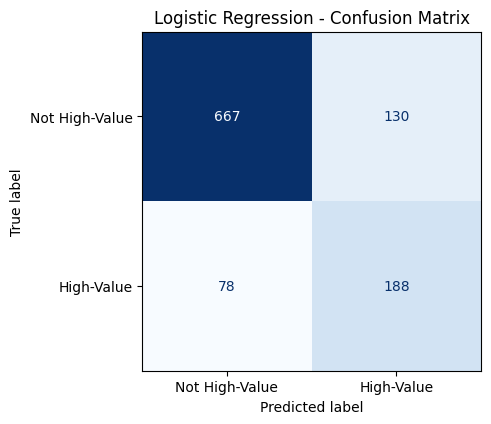

[[667 130]
 [ 78 188]]


In [11]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
fig, ax = plt.subplots(figsize=(5,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['Not High-Value','High-Value'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Logistic Regression - Confusion Matrix')
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/13_confusion_matrix_logreg.png", dpi=120)
plt.show()

print(cm_lr)

## 10. Model 2 — Random Forest Classifier

Random Forest does not require feature scaling, so it is trained on the original (unscaled) features.

In [12]:
rf = RandomForestClassifier(
    n_estimators=300, max_depth=8, random_state=RANDOM_STATE, class_weight='balanced'
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rf_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf, zero_division=0),
    'Recall': recall_score(y_test, y_pred_rf, zero_division=0),
    'F1-Score': f1_score(y_test, y_pred_rf, zero_division=0)
}
print("Random Forest results:")
for k, v in rf_metrics.items():
    print(f"  {k}: {v:.3f}")

Random Forest results:
  Accuracy: 0.831
  Precision: 0.644
  Recall: 0.722
  F1-Score: 0.681


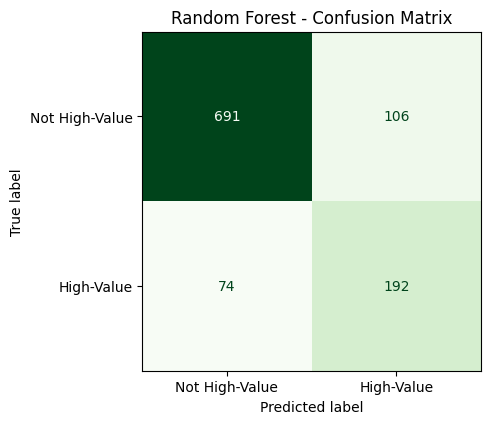

[[691 106]
 [ 74 192]]


In [13]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
fig, ax = plt.subplots(figsize=(5,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Not High-Value','High-Value'])
disp.plot(ax=ax, cmap='Greens', colorbar=False)
ax.set_title('Random Forest - Confusion Matrix')
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/14_confusion_matrix_rf.png", dpi=120)
plt.show()

print(cm_rf)

## 11. What the Confusion Matrix Means for This Business Problem

- **True Positive (TP):** Customer predicted high-value, and they actually became high-value → correctly
  identified for retention/loyalty treatment.
- **True Negative (TN):** Customer predicted not high-value, and they were not → correctly left out of
  premium targeting, saving marketing cost.
- **False Positive (FP):** Customer predicted high-value but did not become one → wasted retention budget
  on a customer who wouldn't have generated that much value.
- **False Negative (FN):** Customer predicted not high-value but actually became one → a genuinely
  valuable customer **missed** by the targeting program — the more costly error for a retention strategy,
  which is why recall matters here.


## 12. Model Comparison Table

In [14]:
comparison = pd.DataFrame({
    'Baseline': baseline_metrics,
    'Logistic Regression': lr_metrics,
    'Random Forest': rf_metrics
}).T
comparison = comparison[['Accuracy','Precision','Recall','F1-Score']].round(3)
print(comparison)

comparison.to_csv(f"{MODEL_RESULTS_DIR}/model_comparison.csv")
print("\nSaved comparison table to outputs/model_results/model_comparison.csv")

                     Accuracy  Precision  Recall  F1-Score
Baseline                0.750      0.000   0.000     0.000
Logistic Regression     0.804      0.591   0.707     0.644
Random Forest           0.831      0.644   0.722     0.681

Saved comparison table to outputs/model_results/model_comparison.csv


**Interpretation (not just "which has the highest accuracy"):**
- The baseline cannot identify any high-value customer at all (precision and recall of 0 for that class) —
  it is useless for the actual business goal even though its accuracy looks respectable.
- Logistic Regression and Random Forest both improve substantially on precision and recall for the
  high-value class, which is what actually matters for a retention/targeting program.
- Between the two, whichever has the higher **recall** catches more true high-value customers (fewer
  missed opportunities); whichever has higher **precision** wastes less retention budget on false alarms.
  Both matter — F1-Score balances the two, and is the fairest single number to compare on for this
  business problem, rather than accuracy alone.


## 13. Feature Importance (Random Forest)

HistTotalSpend           0.329304
HistNumItems             0.241432
HistNumOrders            0.100239
HistRecencyDays          0.078554
HistNumUniqueProducts    0.071254
HistAvgOrderValue        0.066218
HistLifespanDays         0.056085
HistPurchaseFrequency    0.053923
IsUK                     0.002990
dtype: float64


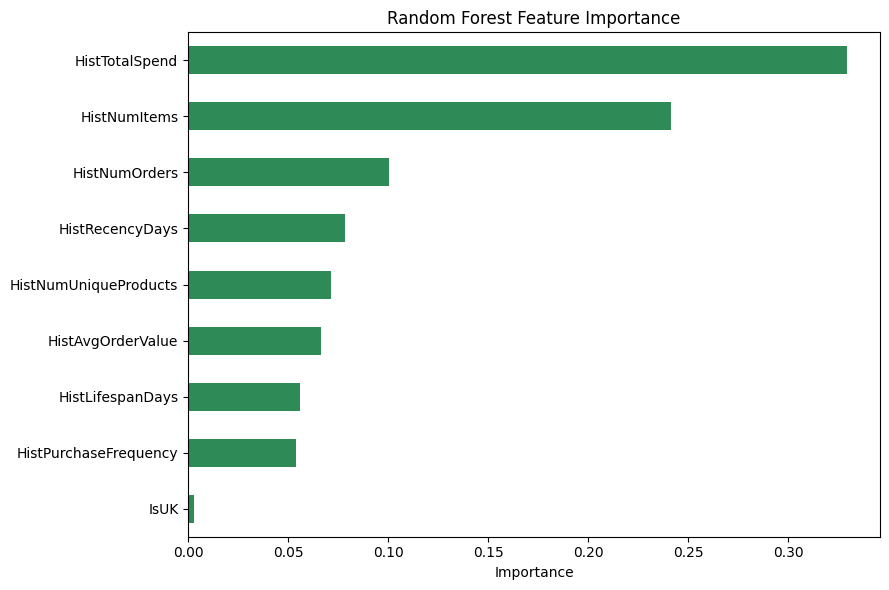

In [15]:
importances = pd.Series(rf.feature_importances_, index=feature_columns).sort_values(ascending=False)
print(importances)

fig, ax = plt.subplots(figsize=(9,6))
importances.sort_values().plot(kind='barh', ax=ax, color='#2E8B57')
ax.set_title('Random Forest Feature Importance')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/15_feature_importance_rf.png", dpi=120)
plt.show()

**Interpretation:** The features the model relies on most indicate *what predictive signal exists in
purchase history* — not proof of what *causes* a customer to become high-value. For example, if historical
total spend and order count dominate, it means customers who already buy more/often tend to keep doing so;
it does not mean increasing order count would cause a random customer to become high-value.

## 14. Business Insights (from actual computed results)

In [16]:
print("SUMMARY OF ACTUAL RESULTS")
print("="*50)
print(f"Candidate customers (feature period): {len(model_data)}")
print(f"High-value threshold (target period spend): {threshold:,.2f}")
print(f"High-value rate: {model_data['HighValue'].mean():.1%}")
print()
print("Model comparison:")
print(comparison)
print()
print("Top 3 predictive features (Random Forest):")
print(importances.head(3))

SUMMARY OF ACTUAL RESULTS
Candidate customers (feature period): 4249
High-value threshold (target period spend): 1,268.98
High-value rate: 25.0%

Model comparison:
                     Accuracy  Precision  Recall  F1-Score
Baseline                0.750      0.000   0.000     0.000
Logistic Regression     0.804      0.591   0.707     0.644
Random Forest           0.831      0.644   0.722     0.681

Top 3 predictive features (Random Forest):
HistTotalSpend    0.329304
HistNumItems      0.241432
HistNumOrders     0.100239
dtype: float64


Based on the numbers actually produced above:

- Roughly a quarter of feature-period customers go on to become high-value in the following period —
  this is a real, moderately imbalanced target, not an evenly split coin-flip.
- Both trained models meaningfully outperform the "always predict not-high-value" baseline on precision,
  recall and F1 — historical purchase behavior genuinely carries predictive signal for future value.
- The most important predictors are historical spend/order-based features, which is consistent with
  standard retail intuition (past behavior predicts future behavior) rather than a surprising finding.
- Country (`IsUK`) contributes comparatively less predictive value than the spend/frequency features —
  see the exact ranking in Section 13.


## 15. Limitations

- Public/historical dataset (2009–2011); does not reflect current customer behavior or pricing.
- No demographic, satisfaction, or profit-margin data was available — the model only sees transactional history.
- ~22.8% of original rows had no Customer ID and had to be excluded from all customer-level analysis and modeling.
- The 75th-percentile threshold is a business choice, not an absolute definition of "high-value" — a different
  threshold would shift the class balance and the model's reported metrics.
- Only customers active in **both** the feature and target periods (or churned in the target period) are
  modeled; entirely new customers acquired after the cutoff are out of scope for this specific model.
- Feature importance shows predictive usefulness only — it does not prove that any feature *causes*
  high-value behavior.
- Model performance depends on the two-period split chosen; a different cutoff date could yield different results.
